In [ ]:
!pip install transformers

In [22]:
from transformers import AutoTokenizer, BertForSequenceClassification, BertTokenizer
import pandas as pd
from sklearn.model_selection import train_test_split
import torch.nn
import torch.optim
from torch.utils.data import Dataset, DataLoader
import torch
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_recall_curve, auc, average_precision_score, roc_curve
from tqdm import tqdm

https://huggingface.co/transformers/v3.0.2/model_doc/bert.html#bertforsequenceclassification

In [23]:
model_type = "ai-forever/ruBert-base"
tokenizer = BertTokenizer.from_pretrained(model_type)
model = BertForSequenceClassification.from_pretrained(model_type)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruBert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
data = pd.read_csv("labeled.csv")
print(data.isna().sum())

comment    0
toxic      0
dtype: int64


In [25]:
train_data, val_data, train_label, val_label = train_test_split(
    data['comment'].tolist(), data['toxic'].tolist(), test_size=0.2, random_state=42)


In [26]:
class CommentsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}, self.labels[idx]

    def __len__(self):
        return len(self.labels)

In [27]:
batch = 16

train_dataset = CommentsDataset(train_data, train_label, tokenizer)
val_dataset = CommentsDataset(val_data, val_label, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=batch, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch, shuffle=True)

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
device

'cuda'

In [29]:
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [30]:
epochs = 3

train_loss = []
train_accuracy = []
train_f1 = []
train_roc_auc = []
train_pr_auc = []

val_loss = []
val_accuracy = []
val_f1 = []
val_roc_auc = []
val_pr_auc = []
fpr = []
tpr = []

for epoch in range(epochs):
  model.train()
  mean_loss = 0

  pred_values = np.array([])
  true_values = np.array([])

  for batch_obj in (pbar := tqdm(train_loader)):
    inputs, labels = batch_obj
    inputs = {k: v.to(device) for k, v in inputs.items()}
    labels = labels.to(device)

    optimizer.zero_grad()

    output = model(**inputs)
    logits = output.logits
    loss_val = loss(logits, labels)
    loss_val.backward()
    optimizer.step()

    #metrics
    mean_loss += loss_val.item()
    probabilities = torch.softmax(logits, dim=1)
    predicted_classes = torch.argmax(probabilities, dim=1)

    pred_values = np.append(pred_values, predicted_classes.cpu())
    true_values = np.append(true_values, labels.cpu())

  len_loader = len(train_loader)
  train_loss.append(mean_loss / len_loader)
  train_accuracy.append(accuracy_score(true_values, pred_values))
  train_f1.append(f1_score(true_values, pred_values))
  train_roc_auc.append(roc_auc_score(true_values, pred_values))
  #precision, recall, thresholds  = precision_recall_curve(true_values, pred_values)
  train_pr_auc.append(average_precision_score(true_values, pred_values))
  t_fpr, t_tpr, _ = roc_curve(true_values, pred_values)
  fpr.append(t_fpr)
  tpr.append(t_tpr)

  model.eval()
  pred_values = np.array([])
  true_values = np.array([])
  mean_val_loss = 0
  for batch_obj in (pbar := tqdm(val_loader)):
    with torch.no_grad():
      inputs, labels = batch_obj
      inputs = {k: v.to(device) for k, v in inputs.items()}
      labels = labels.to(device)

      output = model(**inputs)
      logits = output.logits
      loss_val = loss(logits, labels)
      #metrics
      mean_loss += loss_val.item()
      probabilities = torch.softmax(logits, dim=1)
      predicted_classes = torch.argmax(probabilities, dim=1)
      pred_values = np.append(pred_values, predicted_classes.cpu())
      true_values = np.append(true_values, labels.cpu())

  len_loader = len(val_loader)
  val_loss.append(mean_val_loss / len_loader)
  val_accuracy.append(accuracy_score(true_values, pred_values > 0.5))
  val_f1.append(f1_score(true_values, pred_values > 0.5))
  val_roc_auc.append(roc_auc_score(true_values, pred_values))
  val_pr_auc.append(average_precision_score(true_values, pred_values))


100%|██████████| 181/181 [00:19<00:00,  9.23it/s]


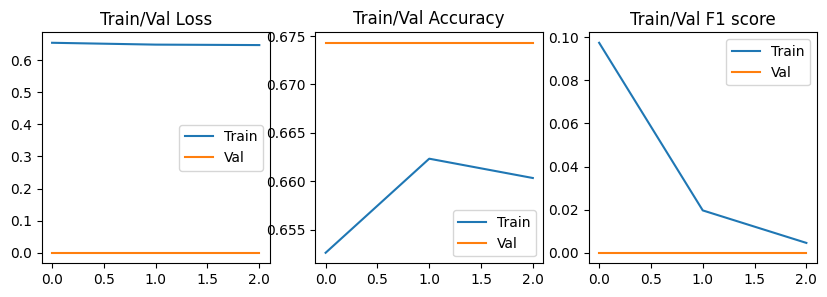

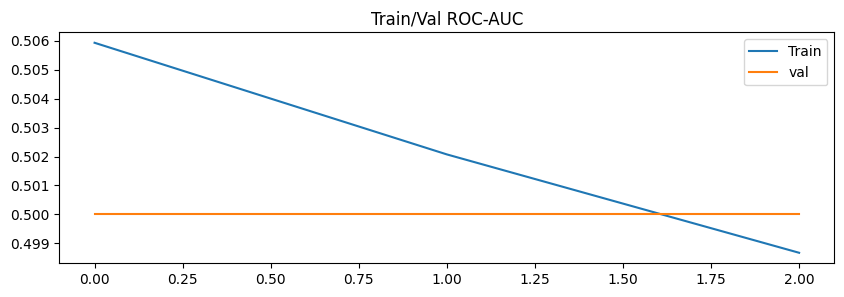

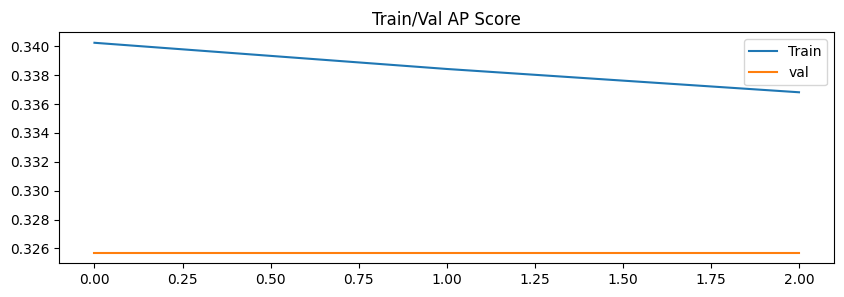

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].plot(range(len(train_loss)), train_loss, label="Train")
ax[0].plot(range(len(val_loss)), val_loss, label="Val")
ax[0].set_title("Train/Val Loss")
ax[0].legend()
ax[1].plot(range(len(train_accuracy)), train_accuracy, label="Train")
ax[1].plot(range(len(val_accuracy)), val_accuracy, label="Val")
ax[1].set_title("Train/Val Accuracy")
ax[1].legend()
ax[2].plot(range(len(train_f1)), train_f1, label="Train")
ax[2].plot(range(len(val_f1)), val_f1, label="Val")
ax[2].set_title("Train/Val F1 score")
ax[2].legend()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(range(len(train_roc_auc)), train_roc_auc, label="Train")
ax.plot(range(len(val_roc_auc)), val_roc_auc, label="val")
ax.set_title("Train/Val ROC-AUC")
ax.legend()
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(range(len(train_pr_auc)), train_pr_auc, label="Train")
ax.plot(range(len(val_pr_auc)), val_pr_auc, label="val")
ax.set_title("Train/Val AP Score")
ax.legend()
plt.show()
